In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

In [76]:
n_signals = 100
nt = 512

x = np.random.randn(n_signals, nt)
dt = 0.5
t = np.arange(nt)*dt

In [77]:
fmax = (1/dt)/2
fmin = 1/(nt*dt)

In [81]:
ps = []

for xi in x:
    
    res = wf.cwt_with_coi(xi, t, freq_min=fmin, freq_max=fmax, nscales=32)
    
    ps.append((res.wt_amp**2).mean('t').data)
freqs = res.f.data

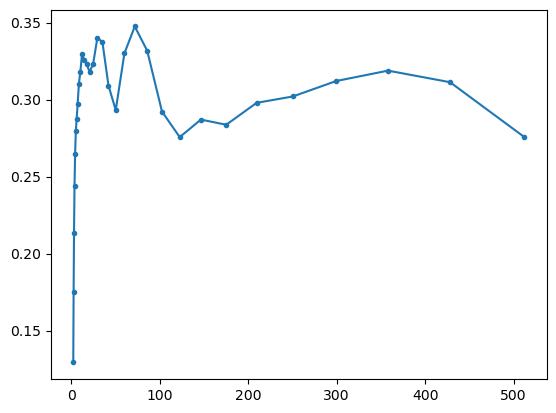

In [91]:
plt.plot(res.scales, np.array(ps).mean(axis=0), marker='.')
# plt.xscale('log')

### Compute energies of the wavelet at all scales:

In [73]:
ts, wls, frqs = wf.scaled_wavelets_pywt(res.attrs['wavelet'], res.scales.data, dt=dt)

In [74]:
wlt_pow = np.sum(abs(wls)**2, axis=1)

Text(0, 0.5, 'total wavelet energy')

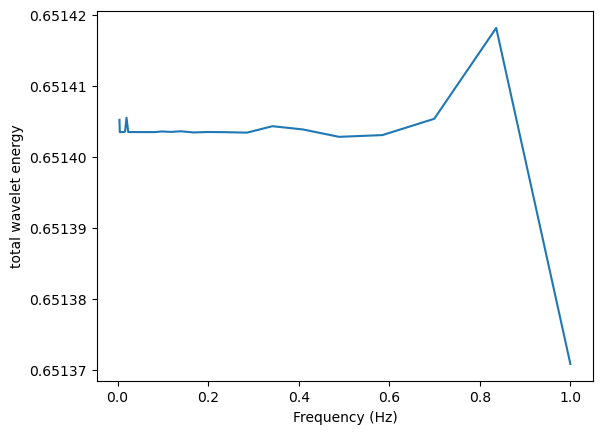

In [75]:
plt.plot(freqs, wlt_pow)
plt.xlabel('Frequency (Hz)')
plt.ylabel('total wavelet energy')
# plt.loglog(freqs, freqs**(-0.5))